# Final Model Evaluation & Comparison

This notebook loads all trained models from `model_weights/` and evaluates them on the held-out 2023 test set. We evaluate both feature versions (`with_covid` and `no_covid`) so we can also compare whether the COVID flag helped.

**Primary metric:** PR-AUC. We also report F2 since missing a cancellation matters more than a false alarm.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100

## Load test data

We load both feature versions (with and without `IS_COVID`) so we can evaluate all models. The test set is 2023 data that no model has seen during training.

In [2]:
test_data = {}
val_data = {}
for version in ['with_covid', 'no_covid']:
    test_data[version] = pd.read_parquet(f'artifacts/X_test_{version}.parquet')
    val_data[version]  = pd.read_parquet(f'artifacts/X_val_{version}.parquet')

y_test = pd.read_parquet('artifacts/y_test.parquet')['CANCELLED'].values
y_val  = pd.read_parquet('artifacts/y_val.parquet')['CANCELLED'].values

feature_names = test_data['with_covid'].columns.tolist()

print(f'Test set: {len(y_test):,} rows  |  cancel rate: {y_test.mean():.2%}')
print(f'With COVID:    {test_data["with_covid"].shape[1]} features')
print(f'Without COVID: {test_data["no_covid"].shape[1]} features')

Test set: 698,587 rows  |  cancel rate: 2.06%
With COVID:    25 features
Without COVID: 24 features


## Evaluation function

One function for all models — computes metrics, stores curves for overlay plots, and shows the confusion matrix.

In [3]:
results = []
pr_curves = {}
roc_curves = {}

def evaluate_model(name, y_true, y_pred, y_proba):
    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'F2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_proba),
        'PR-AUC':    average_precision_score(y_true, y_proba),
    }
    results.append(metrics)

    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    pr_curves[name] = (rec_c, prec_c)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_curves[name] = (fpr, tpr)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=['Operated', 'Cancelled'],
        cmap='Blues', ax=ax, values_format=',')
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:10s}: {v:.4f}')
    return metrics

## Route baseline

Simple dictionary lookup: for each test flight, predict the historical cancellation rate for that ORIGIN-DEST route. No ML involved — just a sanity check that real models beat.

Baseline threshold: 0.03 (val F2 = 0.1175)


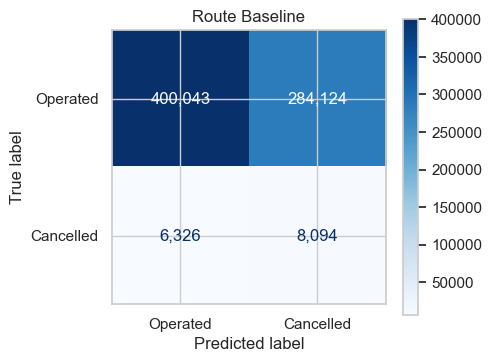

  Accuracy  : 0.5842
  Precision : 0.0277
  Recall    : 0.5613
  F1        : 0.0528
  F2        : 0.1157
  ROC-AUC   : 0.6010
  PR-AUC    : 0.0297


{'Model': 'Route Baseline',
 'Accuracy': 0.5842321715119233,
 'Precision': 0.02769849906576597,
 'Recall': 0.5613037447988904,
 'F1': 0.05279189141593671,
 'F2': 0.11566227872122734,
 'ROC-AUC': np.float64(0.6009663415632759),
 'PR-AUC': np.float64(0.029714832578252637)}

In [4]:
RAW_DATA_PATH = 'flights_with_weather.csv'

if not os.path.exists(RAW_DATA_PATH):
    import kagglehub, glob
    path = kagglehub.dataset_download(
        'huskydawg/flight-cancellation2019-2023-full-with-weather')
    RAW_DATA_PATH = glob.glob(f'{path}/**/*.csv', recursive=True)[0]

df_bl = pd.read_csv(
    RAW_DATA_PATH,
    usecols=['FL_DATE', 'ORIGIN', 'DEST', 'CANCELLED'],
    dtype={'ORIGIN': str, 'DEST': str, 'CANCELLED': 'int8'},
    parse_dates=['FL_DATE'])

train_bl = df_bl[df_bl['FL_DATE'] < '2022-07-01']
val_bl   = df_bl[(df_bl['FL_DATE'] >= '2022-07-01') & (df_bl['FL_DATE'] < '2023-01-01')]
test_bl  = df_bl[df_bl['FL_DATE'] >= '2023-01-01']

route_rates = train_bl.groupby(['ORIGIN', 'DEST'])['CANCELLED'].mean().to_dict()
global_rate = train_bl['CANCELLED'].mean()

def baseline_predict(origins, dests):
    return np.array([route_rates.get((o, d), global_rate) for o, d in zip(origins, dests)])

# tune threshold on validation for F2
val_proba_bl = baseline_predict(val_bl['ORIGIN'].values, val_bl['DEST'].values)
y_val_bl = val_bl['CANCELLED'].values

best_t, best_f2 = 0.5, 0.0
for t in np.linspace(0, 1, 101):
    f2 = fbeta_score(y_val_bl, (val_proba_bl >= t).astype(int), beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2, best_t = f2, t

test_proba_bl = baseline_predict(test_bl['ORIGIN'].values, test_bl['DEST'].values)
test_pred_bl = (test_proba_bl >= best_t).astype(int)

del df_bl, train_bl, val_bl, test_bl

print(f'Baseline threshold: {best_t:.2f} (val F2 = {best_f2:.4f})')
evaluate_model('Route Baseline', y_test, test_pred_bl, test_proba_bl)

## 4. Evaluate all teammate models

Models are loaded from `model_weights/`. For each model type, we look for both `_with_covid` and `_no_covid` versions. Each model's threshold is tuned on validation F2 before test evaluation. Missing files are skipped.


=== Logistic Regression [with_covid] ===
  Threshold: 0.34 (val F2 = 0.1875)


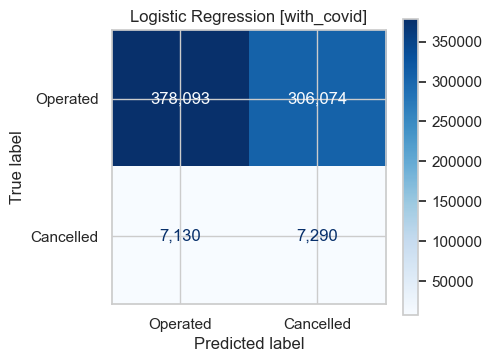

  Accuracy  : 0.5517
  Precision : 0.0233
  Recall    : 0.5055
  F1        : 0.0445
  F2        : 0.0982
  ROC-AUC   : 0.5796
  PR-AUC    : 0.0450

=== Logistic Regression [no_covid] ===
  Threshold: 0.39 (val F2 = 0.1806)


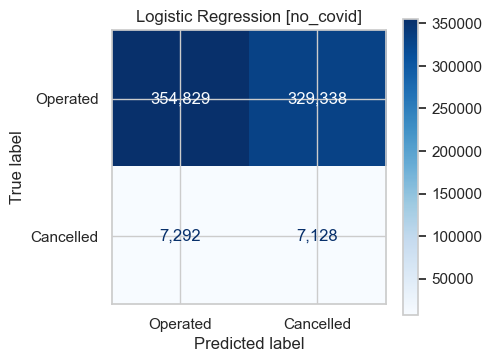

  Accuracy  : 0.5181
  Precision : 0.0212
  Recall    : 0.4943
  F1        : 0.0406
  F2        : 0.0904
  ROC-AUC   : 0.5500
  PR-AUC    : 0.0408

=== Decision Tree [with_covid] ===
  Threshold: 0.47 (val F2 = 0.1822)


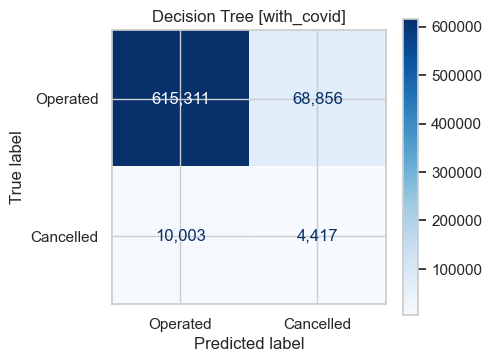

  Accuracy  : 0.8871
  Precision : 0.0603
  Recall    : 0.3063
  F1        : 0.1007
  F2        : 0.1686
  ROC-AUC   : 0.7002
  PR-AUC    : 0.0591

=== Decision Tree [no_covid] ===
  Threshold: 0.41 (val F2 = 0.1908)


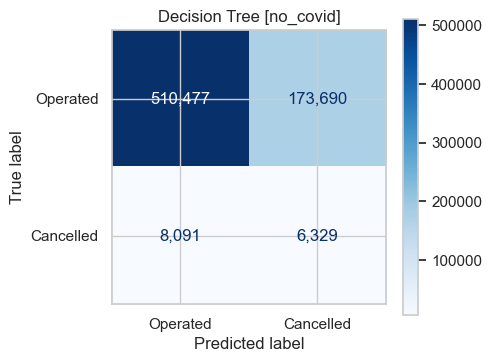

  Accuracy  : 0.7398
  Precision : 0.0352
  Recall    : 0.4389
  F1        : 0.0651
  F2        : 0.1331
  ROC-AUC   : 0.5997
  PR-AUC    : 0.0363

=== Random Forest [with_covid] ===
  Threshold: 0.06 (val F2 = 0.2279)


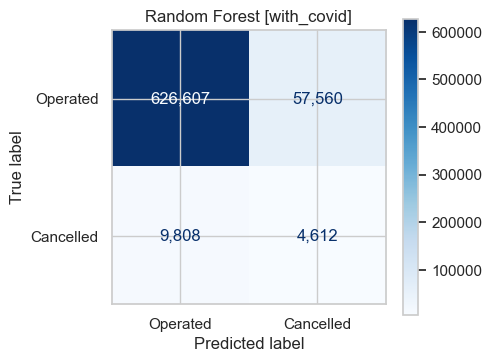

  Accuracy  : 0.9036
  Precision : 0.0742
  Recall    : 0.3198
  F1        : 0.1204
  F2        : 0.1924
  ROC-AUC   : 0.6949
  PR-AUC    : 0.0742

=== Random Forest [no_covid] ===
  Threshold: 0.06 (val F2 = 0.2280)


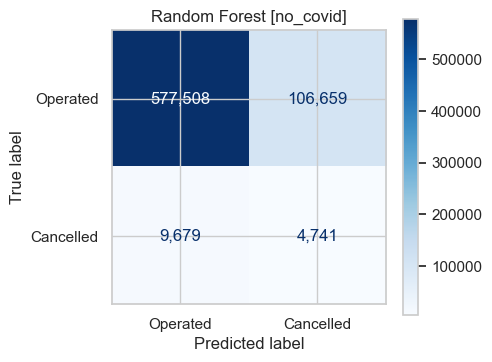

  Accuracy  : 0.8335
  Precision : 0.0426
  Recall    : 0.3288
  F1        : 0.0754
  F2        : 0.1402
  ROC-AUC   : 0.6564
  PR-AUC    : 0.0473

=== XGBoost [with_covid] ===


c:\Users\raphz\anaconda3\Lib\site-packages\xgboost\core.py:751: UserWarning: [20:23:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  Threshold: 0.45 (val F2 = 0.2309)


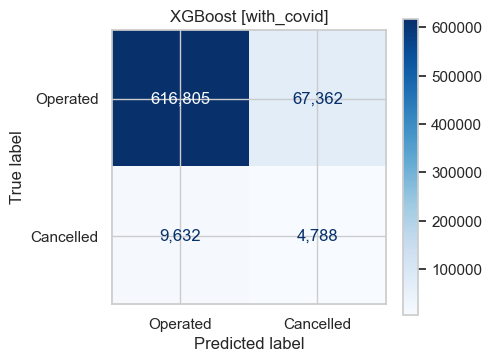

  Accuracy  : 0.8898
  Precision : 0.0664
  Recall    : 0.3320
  F1        : 0.1106
  F2        : 0.1844
  ROC-AUC   : 0.7093
  PR-AUC    : 0.0739

=== XGBoost [no_covid] ===
  Threshold: 0.44 (val F2 = 0.2355)


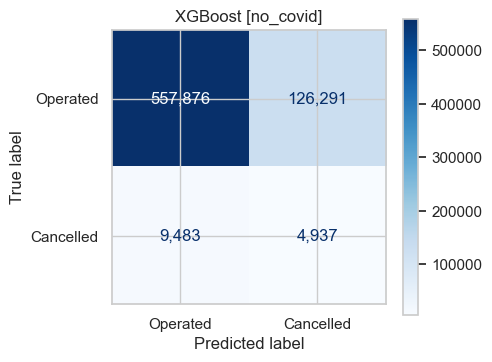

  Accuracy  : 0.8056
  Precision : 0.0376
  Recall    : 0.3424
  F1        : 0.0678
  F2        : 0.1307
  ROC-AUC   : 0.6555
  PR-AUC    : 0.0506

=== Neural Network [with_covid] ===
  Threshold: 0.56 (val F2 = 0.2320)


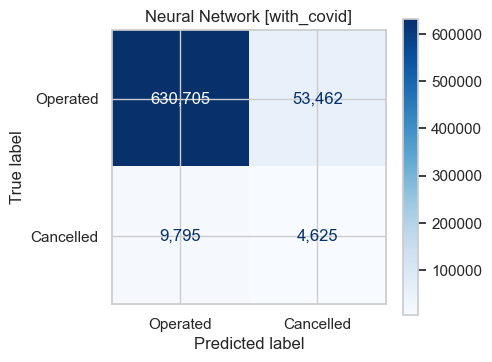

  Accuracy  : 0.9095
  Precision : 0.0796
  Recall    : 0.3207
  F1        : 0.1276
  F2        : 0.1998
  ROC-AUC   : 0.7155
  PR-AUC    : 0.0775

=== Neural Network [no_covid] ===
  Threshold: 0.57 (val F2 = 0.2418)


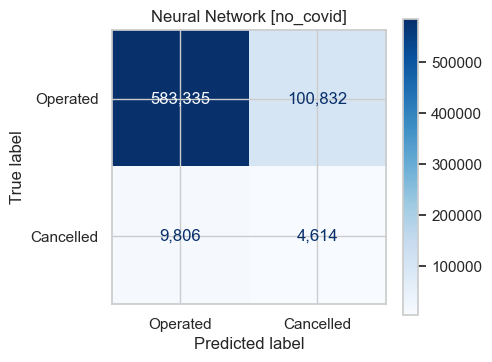

  Accuracy  : 0.8416
  Precision : 0.0438
  Recall    : 0.3200
  F1        : 0.0770
  F2        : 0.1414
  ROC-AUC   : 0.6463
  PR-AUC    : 0.0494


In [5]:
MODEL_DIR = 'model_weights'

# all model types and their file naming pattern
MODEL_TYPES = {
    'Logistic Regression': {'prefix': 'logistic_regression', 'type': 'sklearn'},
    'Decision Tree':       {'prefix': 'decision_tree',       'type': 'sklearn'},
    'Random Forest':       {'prefix': 'random_forest',       'type': 'sklearn'},
    'XGBoost':             {'prefix': 'xgboost',             'type': 'sklearn'},
    'Neural Network':      {'prefix': 'nn',                  'type': 'keras'},
}

loaded_models = {}

def find_best_threshold(y_true, y_proba, beta=2):
    best_t, best_score = 0.5, 0.0
    for t in np.linspace(0, 1, 101):
        score = fbeta_score(y_true, (y_proba >= t).astype(int), beta=beta, zero_division=0)
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score

for model_name, info in MODEL_TYPES.items():
    for version in ['with_covid', 'no_covid']:
        ext = '.keras' if info['type'] == 'keras' else '.pkl'
        filename = f'{info["prefix"]}_{version}{ext}'
        path = os.path.join(MODEL_DIR, filename)

        if not os.path.exists(path):
            print(f'[SKIP] {filename} not found')
            continue

        display_name = f'{model_name} [{version}]'
        print(f'\n=== {display_name} ===')

        if info['type'] == 'keras':
            from tensorflow import keras
            model = keras.models.load_model(path)
            v_proba = model.predict(val_data[version].values, verbose=0).ravel()
            t_proba = model.predict(test_data[version].values, verbose=0).ravel()
        else:
            model = joblib.load(path)
            v_proba = model.predict_proba(val_data[version])[:, 1]
            t_proba = model.predict_proba(test_data[version])[:, 1]

        loaded_models[display_name] = model

        best_t, val_f2 = find_best_threshold(y_val, v_proba)
        print(f'  Threshold: {best_t:.2f} (val F2 = {val_f2:.4f})')

        t_pred = (t_proba >= best_t).astype(int)
        evaluate_model(display_name, y_test, t_pred, t_proba)

if not loaded_models:
    print(f'\nNo models found in {MODEL_DIR}/. Run the model notebooks first.')

## Eval comparison

All models ranked by PR-AUC, with overlay PR and ROC curves.

Final Model Comparison (sorted by PR-AUC):


,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Model,,,,,,,
Neural Network [with_covid],0.9095,0.0796,0.3207,0.1276,0.1998,0.7155,0.0775
Random Forest [with_covid],0.9036,0.0742,0.3198,0.1204,0.1924,0.6949,0.0742
XGBoost [with_covid],0.8898,0.0664,0.3320,0.1106,0.1844,0.7093,0.0739
Decision Tree [with_covid],0.8871,0.0603,0.3063,0.1007,0.1686,0.7002,0.0591
XGBoost [no_covid],0.8056,0.0376,0.3424,0.0678,0.1307,0.6555,0.0506
Neural Network [no_covid],0.8416,0.0438,0.3200,0.0770,0.1414,0.6463,0.0494
Random Forest [no_covid],0.8335,0.0426,0.3288,0.0754,0.1402,0.6564,0.0473
Logistic Regression [with_covid],0.5517,0.0233,0.5055,0.0445,0.0982,0.5796,0.0450
Logistic Regression [no_covid],0.5181,0.0212,0.4943,0.0406,0.0904,0.5500,0.0408


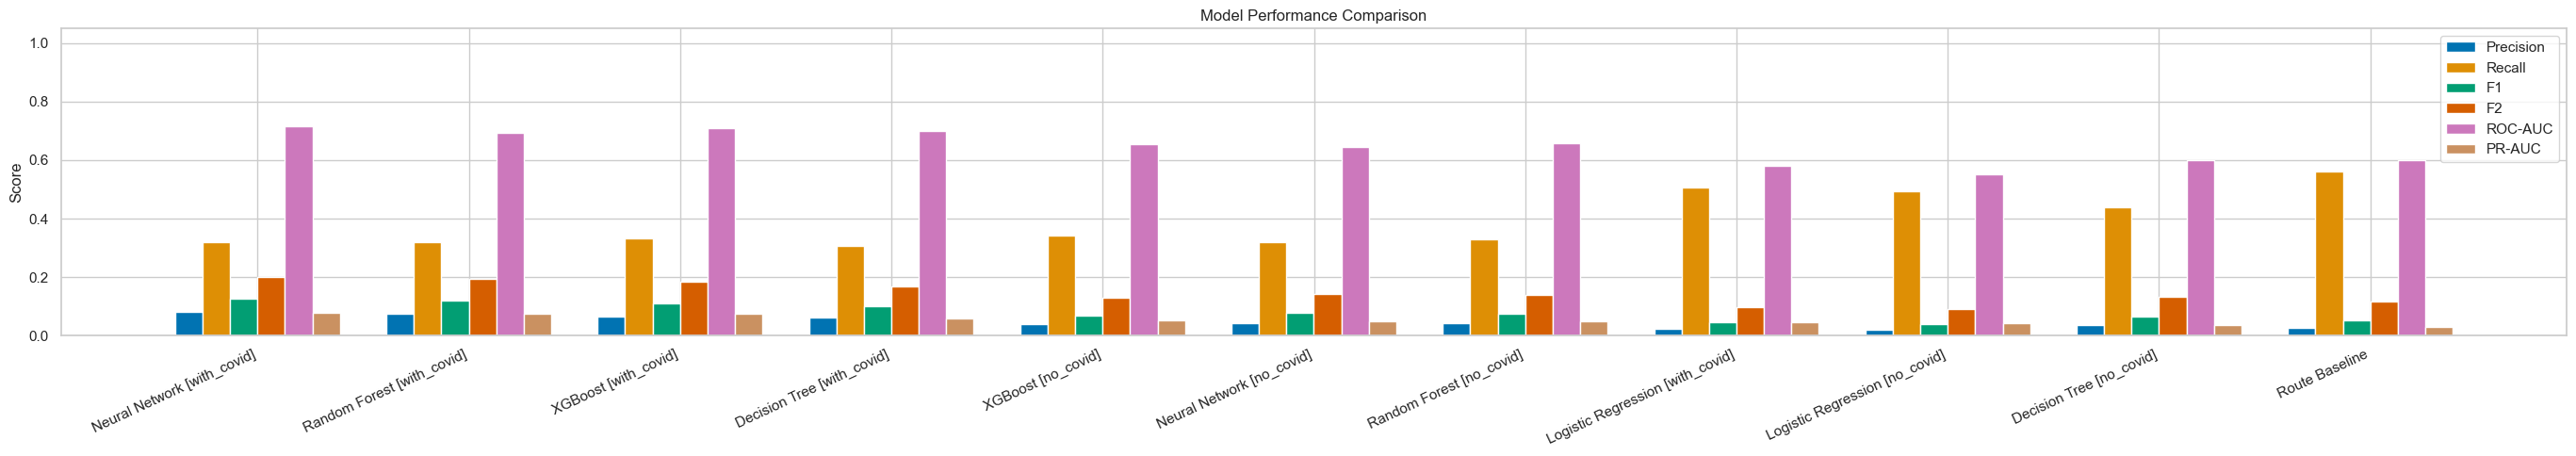

In [6]:
results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)

print('Final Model Comparison (sorted by PR-AUC):')
display(results_df.set_index('Model').style.format('{:.4f}').highlight_max(
    axis=0, props='font-weight:bold; background-color:#d4edda'))

metric_cols = ['Precision', 'Recall', 'F1', 'F2', 'ROC-AUC', 'PR-AUC']

fig, ax = plt.subplots(figsize=(max(12, len(results) * 2.5), 5))
x = np.arange(len(results_df))
width = 0.13
for i, metric in enumerate(metric_cols):
    ax.bar(x + i * width, results_df[metric], width, label=metric)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

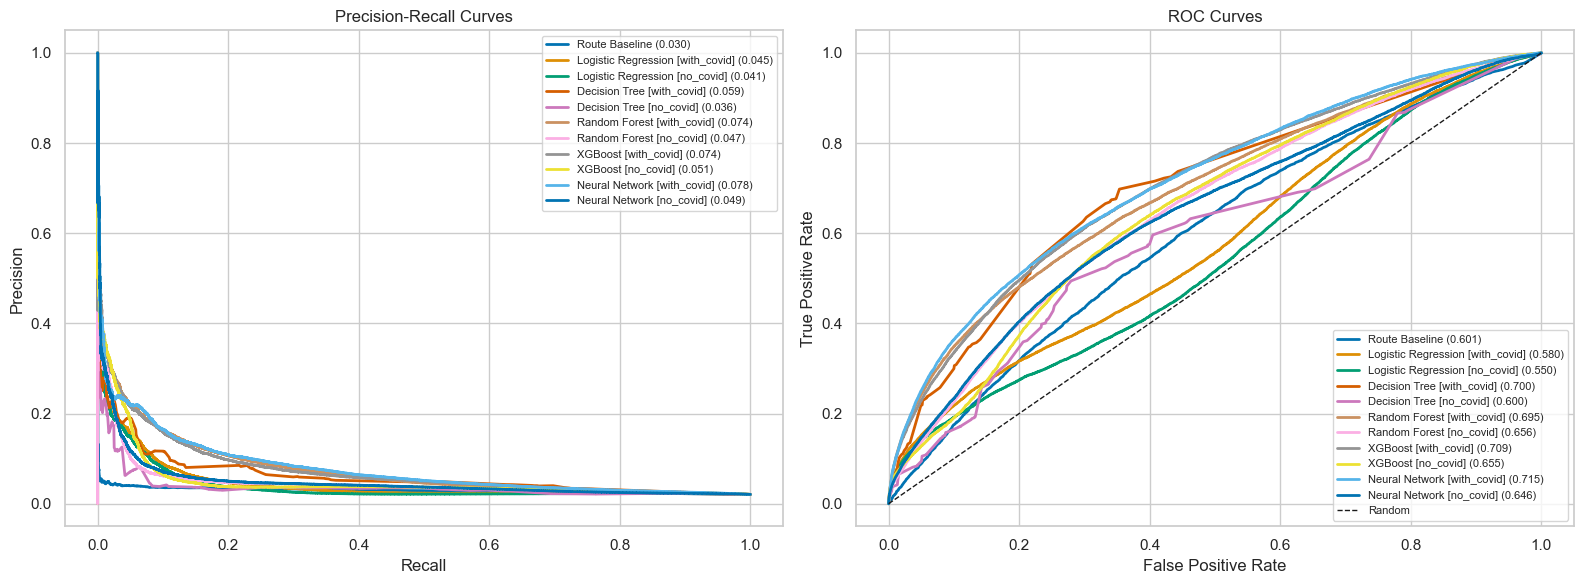

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, (rec_c, prec_c) in pr_curves.items():
    pr_val = next(r['PR-AUC'] for r in results if r['Model'] == name)
    axes[0].plot(rec_c, prec_c, lw=2, label=f'{name} ({pr_val:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(fontsize=8, loc='upper right')

for name, (fpr, tpr) in roc_curves.items():
    roc_val = next(r['ROC-AUC'] for r in results if r['Model'] == name)
    axes[1].plot(fpr, tpr, lw=2, label=f'{name} ({roc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## SHAP interpretability

For the best-performing tree model, SHAP shows which features drive individual predictions. This turns the model from a black box into something we can explain — e.g. "this flight is high-risk because it departs in February from a weather-prone hub on a regional carrier."


=== SHAP analysis: XGBoost [with_covid] ===


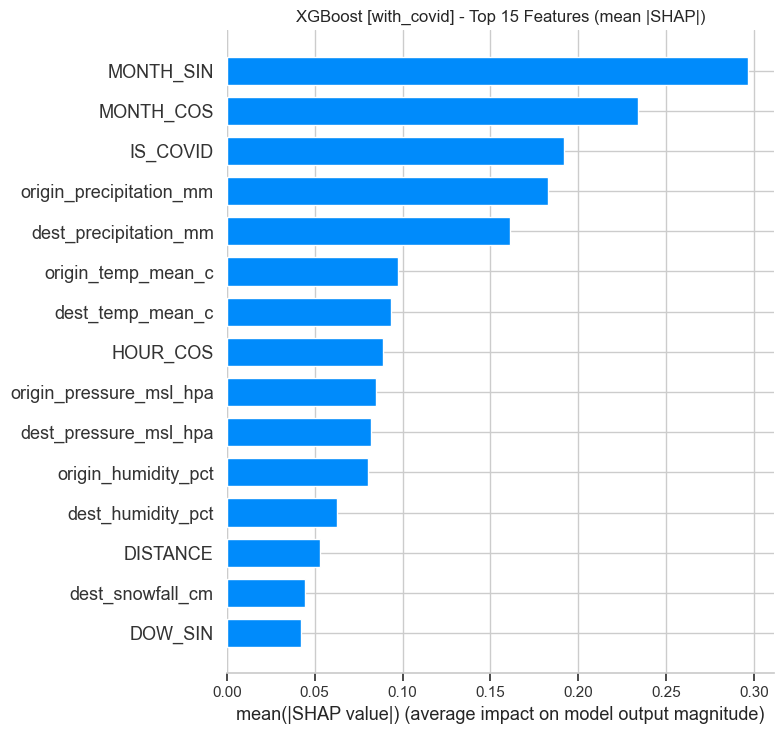

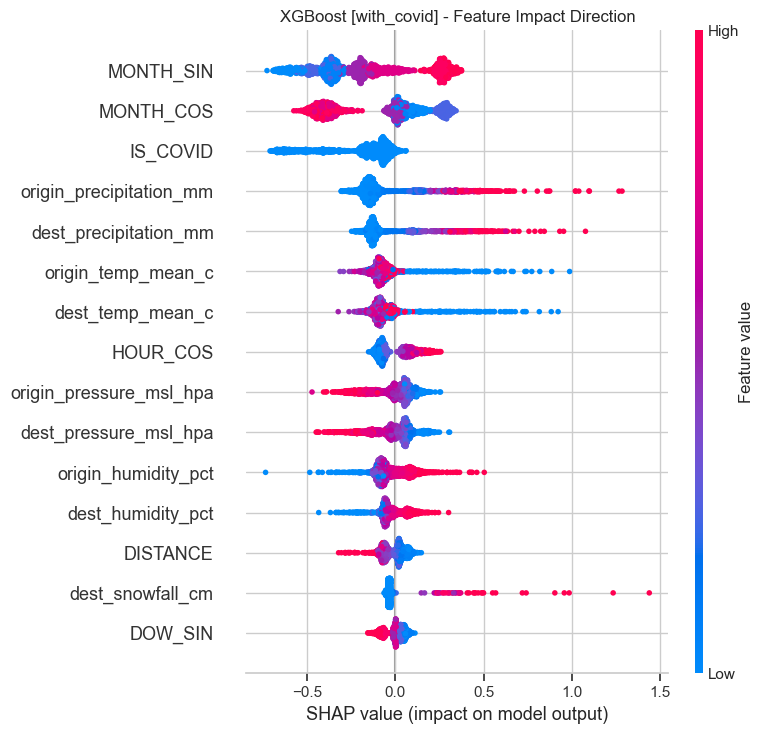

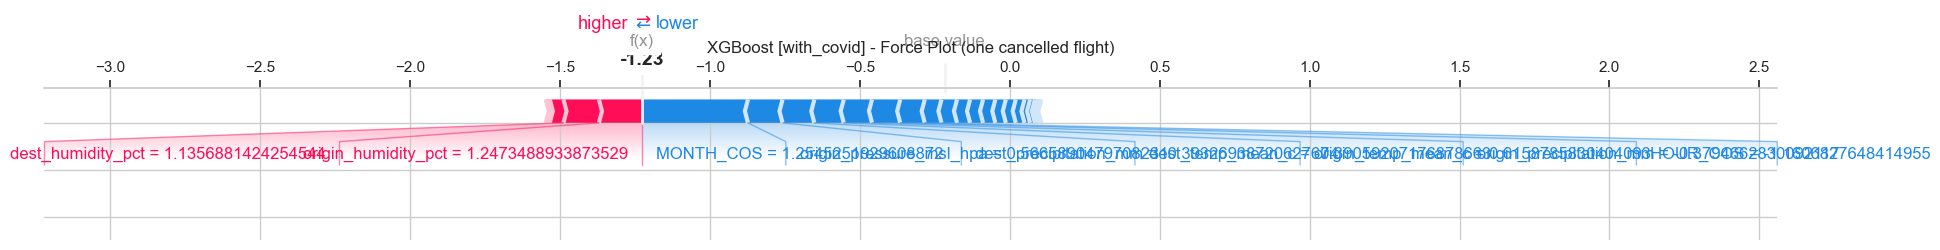


=== SHAP analysis: XGBoost [no_covid] ===


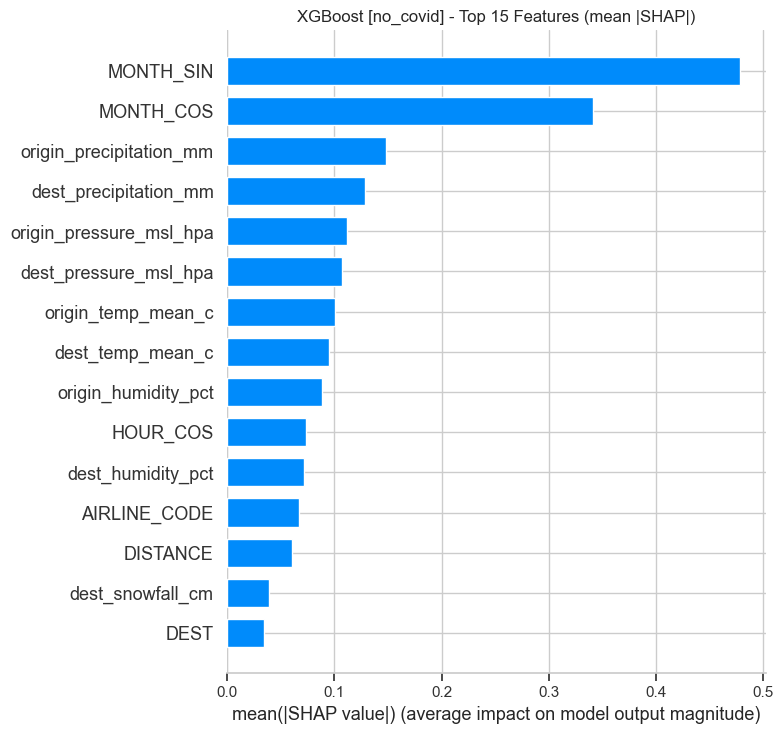

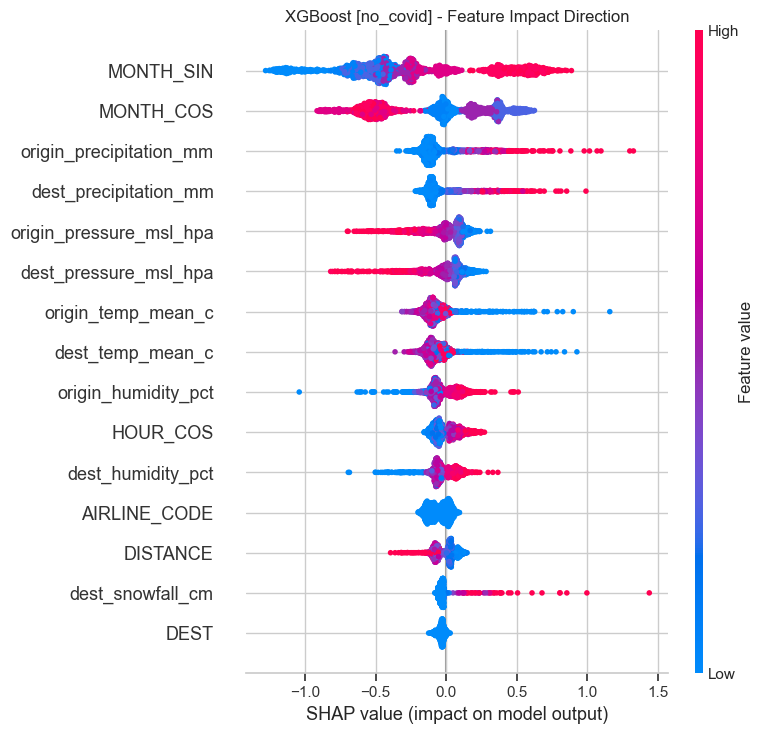

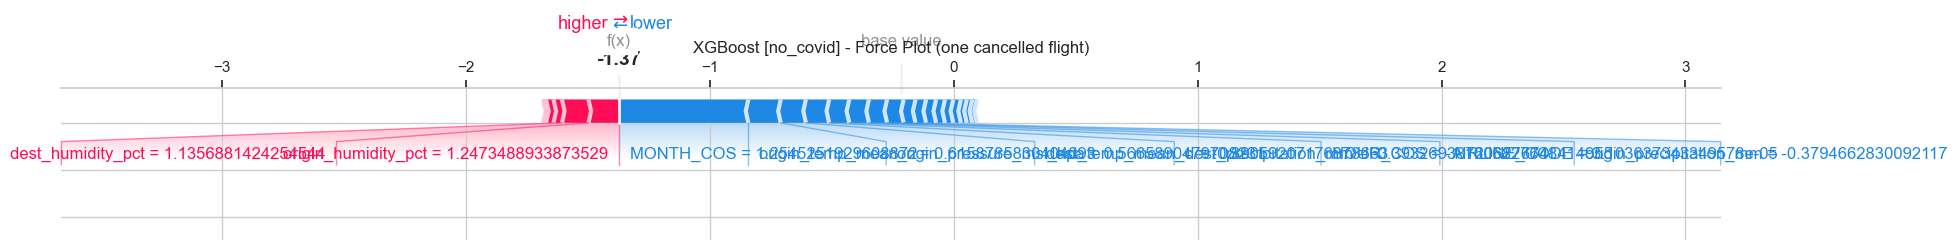

In [11]:
import shap

# Both XGBoost variants — each model must use the matching feature matrix (24 vs 25 cols).
# Using with_covid rows for the no_covid model causes an XGBoost SHAP shape error.
SHAP_SAMPLE_SIZE = 2000
SHAP_TARGETS = ["XGBoost [with_covid]", "XGBoost [no_covid]"]

for model_name in SHAP_TARGETS:
    if model_name not in loaded_models:
        print(f"{model_name} not loaded -- skipping.")
        continue

    version_key = "with_covid" if "with_covid" in model_name else "no_covid"
    X_shap = test_data[version_key]
    shap_sample = X_shap.sample(n=min(SHAP_SAMPLE_SIZE, len(X_shap)), random_state=42)

    print(f"\n=== SHAP analysis: {model_name} ===")
    model = loaded_models[model_name]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(shap_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # positive-class for classifiers

    # Bar plot: mean |SHAP| per feature
    shap.summary_plot(shap_values, shap_sample, plot_type="bar",
                      max_display=15, show=False)
    plt.title(f"{model_name} - Top 15 Features (mean |SHAP|)")
    plt.tight_layout()
    plt.show()

    # Beeswarm plot: direction of feature impact
    shap.summary_plot(shap_values, shap_sample, max_display=15, show=False)
    plt.title(f"{model_name} - Feature Impact Direction")
    plt.tight_layout()
    plt.show()

    # Force plot: one example cancelled flight
    cancelled_idx = np.where(y_test == 1)[0]
    if len(cancelled_idx) > 0:
        p = cancelled_idx[0]
        row = X_shap.iloc[[p]]
        sv = explainer.shap_values(row)
        if isinstance(sv, list):
            sv = sv[1]
        ev = explainer.expected_value
        if isinstance(ev, list):
            ev = ev[1]
        shap.force_plot(ev, sv, features=row, matplotlib=True, show=False)
        plt.title(f"{model_name} - Force Plot (one cancelled flight)")
        plt.tight_layout()
        plt.show()

## Save results

In [9]:
results_df.to_csv('artifacts/model_comparison.csv', index=False)
print('Saved artifacts/model_comparison.csv')
print(results_df.to_string(index=False))

Saved artifacts/model_comparison.csv
                           Model  Accuracy  Precision   Recall       F1       F2  ROC-AUC   PR-AUC
     Neural Network [with_covid]  0.909450   0.079622 0.320735 0.127574 0.199755 0.715457 0.077508
      Random Forest [with_covid]  0.903565   0.074181 0.319834 0.120430 0.192404 0.694871 0.074240
            XGBoost [with_covid]  0.889786   0.066362 0.332039 0.110616 0.184395 0.709313 0.073926
      Decision Tree [with_covid]  0.887116   0.060281 0.306311 0.100738 0.168648 0.700233 0.059065
              XGBoost [no_covid]  0.805645   0.037622 0.342372 0.067794 0.130672 0.655496 0.050569
       Neural Network [no_covid]  0.841626   0.043757 0.319972 0.076986 0.141424 0.646349 0.049436
        Random Forest [no_covid]  0.833467   0.042558 0.328779 0.075362 0.140200 0.656356 0.047278
Logistic Regression [with_covid]  0.551661   0.023264 0.505548 0.044481 0.098236 0.579600 0.045038
  Logistic Regression [no_covid]  0.518127   0.021185 0.494313 0.040629 